# Сравнение оптимизаторов на бенчмарках

Сравнение NSGA-II, NSGA-III и MOEA/D на стандартных многоцелевых бенчмарках:
- **ZDT1-6** - классические задачи (2 цели)
- **DTLZ1-7** - масштабируемые задачи (3+ целей)
- **UF1-10** - несепарабельные задачи (2 цели)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.decomposition.pbi import PBI
from pymoo.decomposition.aasf import AASF
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.problems.many import DTLZ, WFG

# Import our custom functions
import sys
sys.path.insert(0, '/Users/andreyfeduhin/Downloads/Urbanomy/src')
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import (
    build_nsga3_reference_directions
)

# Для UF проблем используем CEC2009
try:
    from pymoo.problems.single import G1, G10
    HAS_CEC = True
except:
    HAS_CEC = False

print("Импорты выполнены успешно!")
print(f"CEC problems available: {HAS_CEC}")

Импорты выполнены успешно!
CEC problems available: True


## Сравнение оптимизаторов на бенчмарках

In [2]:
def run_optimizer(optimizer, problem, generations=100, seed=42, verbose=False):
    """Запустить оптимизатор и вернуть результат."""
    result = minimize(
        problem,
        optimizer,
        termination=("n_gen", generations),
        seed=seed,
        verbose=verbose,
        save_history=True,
    )
    return result


def calculate_hypervolume(F, ref_point=None):
    """Вычислить Hypervolume для набора решений."""
    try:
        if ref_point is None:
            # Используем максимальные значения целевых функций как точку отсчета
            ref_point = np.max(F, axis=0) * 1.1  # На 10% больше максимума
        
        hv = HV(ref_point=ref_point)
        return hv(F)
    except Exception as e:
        return None


def evaluate_result(result, problem_name, algorithm_name, problem=None):
    """Оценить качество результата оптимизации."""
    F = result.F
    
    metrics = {
        "Problem": problem_name,
        "Algorithm": algorithm_name,
        "N_Solutions": len(F),
        "Min_F1": float(np.min(F[:, 0])) if F.shape[1] > 0 else None,
        "Max_F1": float(np.max(F[:, 0])) if F.shape[1] > 0 else None,
        "Mean_F1": float(np.mean(F[:, 0])) if F.shape[1] > 0 else None,
    }
    
    if F.shape[1] > 1:
        metrics["Min_F2"] = float(np.min(F[:, 1]))
        metrics["Max_F2"] = float(np.max(F[:, 1]))
        metrics["Mean_F2"] = float(np.mean(F[:, 1]))
    
    # Вычисляем Hypervolume
    hv = calculate_hypervolume(F)
    metrics["Hypervolume"] = hv
    
    return metrics


print("Функции для оценки готовы (с Hypervolume)")

Функции для оценки готовы (с Hypervolume)


## ZDT Benchmarks (2 целей)

In [3]:
# ZDT Benchmarks
zdt_problems = [f"zdt{i}" for i in range(1, 7)]
zdt_results = []

for problem_name in zdt_problems:
    problem = get_problem(problem_name)
    pop_size = 30
    generations = 50
    
    print(f"\n{'='*60}")
    print(f"Problem: {problem_name.upper()} (n_var={problem.n_var}, n_obj={problem.n_obj})")
    print(f"{'='*60}")
    
    # NSGA-II
    print("Running NSGA-II...")
    nsga2 = NSGA2(pop_size=pop_size, eliminate_duplicates=True)
    res_nsga2 = run_optimizer(nsga2, problem, generations=generations, seed=42)
    metrics_nsga2 = evaluate_result(res_nsga2, problem_name, "NSGA-II")
    zdt_results.append(metrics_nsga2)
    print(f"  Solutions: {len(res_nsga2.F)}")
    
    # NSGA-III
    print("Running NSGA-III...")
    ref_dirs = build_nsga3_reference_directions(
        n_obj=problem.n_obj, pop_size=pop_size, n_partitions=12
    )
    nsga3 = NSGA3(ref_dirs=ref_dirs, pop_size=pop_size, eliminate_duplicates=True)
    res_nsga3 = run_optimizer(nsga3, problem, generations=generations, seed=42)
    metrics_nsga3 = evaluate_result(res_nsga3, problem_name, "NSGA-III")
    zdt_results.append(metrics_nsga3)
    print(f"  Solutions: {len(res_nsga3.F)}")
    
    # MOEA/D
    print("Running MOEA/D...")
    ref_dirs_moead = build_nsga3_reference_directions(
        n_obj=problem.n_obj, pop_size=pop_size, n_partitions=10
    )
    moead = MOEAD(
        ref_dirs=ref_dirs_moead,
        n_neighbors=20,
        decomposition=PBI(),
        prob_neighbor_mating=0.7,
    )
    res_moead = run_optimizer(moead, problem, generations=generations, seed=42)
    metrics_moead = evaluate_result(res_moead, problem_name, "MOEA/D")
    zdt_results.append(metrics_moead)
    print(f"  Solutions: {len(res_moead.F)}")

# Создаем DataFrame для ZDT результатов
zdt_df = pd.DataFrame(zdt_results)
print("\n" + "="*60)
print("ZDT Results Summary")
print("="*60)
print(zdt_df.to_string())


Problem: ZDT1 (n_var=30, n_obj=2)
Running NSGA-II...
  Solutions: 29
Running NSGA-III...
  Solutions: 12
Running MOEA/D...
  Solutions: 29
Running NSGA-III...
  Solutions: 12
Running MOEA/D...
  Solutions: 7

Problem: ZDT2 (n_var=30, n_obj=2)
Running NSGA-II...
  Solutions: 13
Running NSGA-III...
  Solutions: 7

Problem: ZDT2 (n_var=30, n_obj=2)
Running NSGA-II...
  Solutions: 13
Running NSGA-III...
  Solutions: 2
Running MOEA/D...
  Solutions: 11

Problem: ZDT3 (n_var=30, n_obj=2)
Running NSGA-II...
  Solutions: 2
Running MOEA/D...
  Solutions: 11

Problem: ZDT3 (n_var=30, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 11
Running MOEA/D...
  Solutions: 30
Running NSGA-III...
  Solutions: 11
Running MOEA/D...
  Solutions: 9

Problem: ZDT4 (n_var=10, n_obj=2)
Running NSGA-II...
  Solutions: 9
Running NSGA-III...
  Solutions: 5
Running MOEA/D...
  Solutions: 9

Problem: ZDT4 (n_var=10, n_obj=2)
Running NSGA-II...
  Solutions: 9
Running NSGA-III...
  Solutio

## DTLZ Benchmarks (многоцелевые)

In [4]:
# DTLZ Benchmarks
dtlz_problems = [f"dtlz{i}" for i in range(1, 8)]
dtlz_results = []

for problem_name in dtlz_problems:
    problem = get_problem(problem_name, n_obj=3)
    pop_size = 30
    generations = 50
    
    print(f"\n{'='*60}")
    print(f"Problem: {problem_name.upper()} (n_var={problem.n_var}, n_obj={problem.n_obj})")
    print(f"{'='*60}")
    
    # NSGA-II
    print("Running NSGA-II...")
    nsga2 = NSGA2(pop_size=pop_size, eliminate_duplicates=True)
    res_nsga2 = run_optimizer(nsga2, problem, generations=generations, seed=42)
    metrics_nsga2 = evaluate_result(res_nsga2, problem_name, "NSGA-II")
    dtlz_results.append(metrics_nsga2)
    print(f"  Solutions: {len(res_nsga2.F)}")
    
    # NSGA-III
    print("Running NSGA-III...")
    ref_dirs = build_nsga3_reference_directions(
        n_obj=problem.n_obj, pop_size=pop_size, n_partitions=12
    )
    nsga3 = NSGA3(ref_dirs=ref_dirs, pop_size=pop_size, eliminate_duplicates=True)
    res_nsga3 = run_optimizer(nsga3, problem, generations=generations, seed=42)
    metrics_nsga3 = evaluate_result(res_nsga3, problem_name, "NSGA-III")
    dtlz_results.append(metrics_nsga3)
    print(f"  Solutions: {len(res_nsga3.F)}")
    
    # MOEA/D
    print("Running MOEA/D...")
    ref_dirs_moead = build_nsga3_reference_directions(
        n_obj=problem.n_obj, pop_size=pop_size, n_partitions=10
    )
    moead = MOEAD(
        ref_dirs=ref_dirs_moead,
        n_neighbors=20,
        decomposition=PBI(),
        prob_neighbor_mating=0.7,
    )
    res_moead = run_optimizer(moead, problem, generations=generations, seed=42)
    metrics_moead = evaluate_result(res_moead, problem_name, "MOEA/D")
    dtlz_results.append(metrics_moead)
    print(f"  Solutions: {len(res_moead.F)}")

# Создаем DataFrame для DTLZ результатов
dtlz_df = pd.DataFrame(dtlz_results)
print("\n" + "="*60)
print("DTLZ Results Summary")
print("="*60)
print(dtlz_df.to_string())


Problem: DTLZ1 (n_var=7, n_obj=3)
Running NSGA-II...
  Solutions: 28
Running NSGA-III...
This might cause unwanted behavior of the algorithm. 
Please make sure pop_size is equal or larger than the number of reference directions. 
  Solutions: 13
Running MOEA/D...
  Solutions: 28
Running NSGA-III...
This might cause unwanted behavior of the algorithm. 
Please make sure pop_size is equal or larger than the number of reference directions. 
  Solutions: 13
Running MOEA/D...
  Solutions: 65

Problem: DTLZ2 (n_var=10, n_obj=3)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
This might cause unwanted behavior of the algorithm. 
Please make sure pop_size is equal or larger than the number of reference directions. 
  Solutions: 39
Running MOEA/D...
  Solutions: 65

Problem: DTLZ2 (n_var=10, n_obj=3)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
This might cause unwanted behavior of the algorithm. 
Please make sure pop_size is equal or larger than the number of reference directi

## WFG Benchmarks (сложные многоцелевые задачи)

In [6]:
# WFG Benchmarks - требуют явного указания n_var и n_obj
print("\n" + "="*80)
print("Тестирование на задачах WFG (сложные многоцелевые)")
print("="*80 + "\n")

# WFG проблемы требуют n_var и n_obj
wfg_configs = [
    (1, 12, 2),   # WFG1: n_var=12, n_obj=2
    (2, 12, 2),   # WFG2: n_var=12, n_obj=2
    (3, 12, 2),   # WFG3: n_var=12, n_obj=2
    (4, 12, 2),   # WFG4: n_var=12, n_obj=2
    (5, 12, 2),   # WFG5: n_var=12, n_obj=2
    (6, 12, 2),   # WFG6: n_var=12, n_obj=2
    (7, 12, 2),   # WFG7: n_var=12, n_obj=2
    (8, 12, 2),   # WFG8: n_var=12, n_obj=2
    (9, 12, 2),   # WFG9: n_var=12, n_obj=2
]

wfg_results = []

for wfg_num, n_var, n_obj in wfg_configs:
    try:
        problem_name = f'wfg{wfg_num}'
        # Создаем WFG проблему с явными параметрами
        problem = WFG(n_var=n_var, n_obj=n_obj, problem_id=wfg_num)
        
        pop_size = 30
        generations = 50
        
        print(f"\n{'='*60}")
        print(f"Problem: {problem_name.upper()} (n_var={problem.n_var}, n_obj={problem.n_obj})")
        print(f"{'='*60}")
        
        # NSGA-II
        print("Running NSGA-II...")
        nsga2 = NSGA2(pop_size=pop_size, eliminate_duplicates=True)
        res_nsga2 = run_optimizer(nsga2, problem, generations=generations, seed=42)
        metrics_nsga2 = evaluate_result(res_nsga2, problem_name, "NSGA-II")
        wfg_results.append(metrics_nsga2)
        print(f"  Solutions: {len(res_nsga2.F)}")
        
        # NSGA-III
        print("Running NSGA-III...")
        ref_dirs = build_nsga3_reference_directions(
            n_obj=problem.n_obj, pop_size=pop_size, n_partitions=12
        )
        nsga3 = NSGA3(ref_dirs=ref_dirs, pop_size=pop_size, eliminate_duplicates=True)
        res_nsga3 = run_optimizer(nsga3, problem, generations=generations, seed=42)
        metrics_nsga3 = evaluate_result(res_nsga3, problem_name, "NSGA-III")
        wfg_results.append(metrics_nsga3)
        print(f"  Solutions: {len(res_nsga3.F)}")
        
        # MOEA/D
        print("Running MOEA/D...")
        ref_dirs_moead = build_nsga3_reference_directions(
            n_obj=problem.n_obj, pop_size=pop_size, n_partitions=10
        )
        moead = MOEAD(
            ref_dirs=ref_dirs_moead,
            n_neighbors=20,
            decomposition=PBI(),
            prob_neighbor_mating=0.7,
        )
        res_moead = run_optimizer(moead, problem, generations=generations, seed=42)
        metrics_moead = evaluate_result(res_moead, problem_name, "MOEA/D")
        wfg_results.append(metrics_moead)
        print(f"  Solutions: {len(res_moead.F)}")
        
    except Exception as e:
        print(f"Skipping {problem_name}: {e}")
        continue

# Создаем DataFrame для WFG результатов
wfg_df = pd.DataFrame(wfg_results)
print("\n" + "="*60)
print("WFG Results Summary")
print("="*60)
if len(wfg_df) > 0:
    print(wfg_df.to_string())
else:
    print("No results available")


Тестирование на задачах WFG (сложные многоцелевые)


Problem: WFG1 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG2 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG2 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG3 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG3 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG4 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running MOEA/D...
  Solutions: 11

Problem: WFG4 (n_var=12, n_obj=2)
Running NSGA-II...
  Solutions: 30
Running NSGA-III...
  Solutions: 1
Running 

## Сводное сравнение


Статистика по алгоритмам (включая Hypervolume)
          N_Solutions                 Mean_F1  Hypervolume                \
                 mean     std min max    mean         mean           std   
Algorithm                                                                  
MOEA/D         35.462  25.330   7  66   0.954       69.618  2.072290e+02   
NSGA-II        24.846   8.792   7  30   6.842  3930848.094  1.385207e+07   
NSGA-III       14.000  12.042   2  39   3.797    81310.708  2.887444e+05   

                                
             min           max  
Algorithm                       
MOEA/D     0.000  7.439220e+02  
NSGA-II    0.084  5.002265e+07  
NSGA-III   0.000  1.042216e+06  


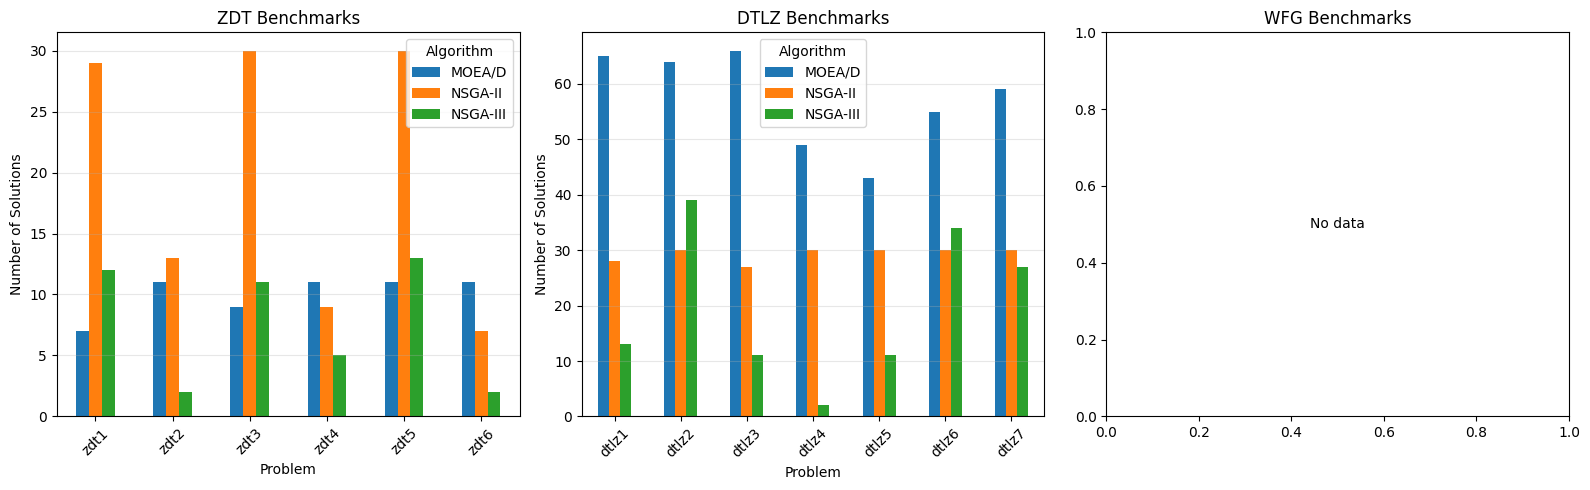


График сохранен в /tmp/benchmark_comparison.png


In [20]:
# Объединяем все результаты
all_results = pd.concat([zdt_df, dtlz_df, wfg_df], ignore_index=True)

# Подсчитываем количество решений по алгоритмам
algo_stats = all_results.groupby('Algorithm').agg({
    'N_Solutions': ['mean', 'std', 'min', 'max'],
    'Mean_F1': 'mean',
    'Hypervolume': ['mean', 'std', 'min', 'max'],
}).round(3)

print("\n" + "="*80)
print("Статистика по алгоритмам (включая Hypervolume)")
print("="*80)
print(algo_stats)

# Визуализация: количество решений по типам задач
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (df, title) in enumerate([
    (zdt_df, 'ZDT Benchmarks'),
    (dtlz_df, 'DTLZ Benchmarks'),
    (wfg_df, 'WFG Benchmarks')
]):
    if len(df) > 0:
        pivot_data = df.pivot_table(
            values='N_Solutions',
            index='Problem',
            columns='Algorithm',
            aggfunc='first'
        )
        pivot_data.plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(title)
        axes[idx].set_ylabel('Number of Solutions')
        axes[idx].set_xlabel('Problem')
        axes[idx].legend(title='Algorithm')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
    else:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(title)

plt.tight_layout()
plt.savefig('/tmp/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен в /tmp/benchmark_comparison.png")

In [21]:
# Подробное сравнение по каждому типу задач
print("\n" + "="*80)
print("ДЕТАЛЬНОЕ СРАВНЕНИЕ (с Hypervolume)")
print("="*80)

print("\n--- ZDT Benchmarks (2 objectives) ---")
if len(zdt_df) > 0:
    print(zdt_df[['Problem', 'Algorithm', 'N_Solutions', 'Mean_F1', 'Mean_F2', 'Hypervolume']].to_string(index=False))

print("\n--- DTLZ Benchmarks (3 objectives) ---")
if len(dtlz_df) > 0:
    print(dtlz_df[['Problem', 'Algorithm', 'N_Solutions', 'Mean_F1', 'Mean_F2', 'Hypervolume']].to_string(index=False))

print("\n--- WFG Benchmarks (многоцелевые) ---")
if len(wfg_df) > 0:
    print(wfg_df[['Problem', 'Algorithm', 'N_Solutions', 'Mean_F1', 'Mean_F2', 'Hypervolume']].to_string(index=False))
else:
    print("No WFG results available")

# Сводная таблица по Hypervolume
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА - HYPERVOLUME (больше = лучше)")
print("="*80)

for bench_name, bench_df in [('ZDT', zdt_df), ('DTLZ', dtlz_df), ('WFG', wfg_df)]:
    if len(bench_df) > 0:
        print(f"\n{bench_name}:")
        hv_pivot = bench_df.pivot_table(
            values='Hypervolume',
            index='Problem',
            columns='Algorithm',
            aggfunc='first'
        )
        print(hv_pivot.to_string())
        
        # Средние значения Hypervolume
        mean_hv = bench_df.groupby('Algorithm')['Hypervolume'].mean().round(3)
        print(f"\nСредний Hypervolume для {bench_name}: \n{mean_hv.to_string()}\n")


ДЕТАЛЬНОЕ СРАВНЕНИЕ (с Hypervolume)

--- ZDT Benchmarks (2 objectives) ---
Problem Algorithm  N_Solutions      Mean_F1   Mean_F2  Hypervolume
   zdt1   NSGA-II           29 3.235314e-01  1.602158 1.093484e+00
   zdt1  NSGA-III           12 3.479921e-01  1.122925 9.608050e-01
   zdt1    MOEA/D            7 3.950595e-01  2.796664 3.415563e-01
   zdt2   NSGA-II           13 6.123474e-01  1.673902 4.540183e-01
   zdt2  NSGA-III            2 1.696754e-07  1.841139 6.438223e-08
   zdt2    MOEA/D           11 2.967065e-03  2.976666 8.831961e-05
   zdt3   NSGA-II           30 4.209431e-01  0.867977 1.164211e+00
   zdt3  NSGA-III           11 4.498566e-01  0.917752 1.280123e+00
   zdt3    MOEA/D            9 5.827169e-01  2.163402 9.773215e-01
   zdt4   NSGA-II            9 1.093336e-01 16.526722 1.054142e+01
   zdt4  NSGA-III            5 1.296462e-07 16.141198 1.467596e-05
   zdt4    MOEA/D           11 5.489768e-01 11.445618 6.283379e-02
   zdt5   NSGA-II           30 3.228930e-01  0.276420

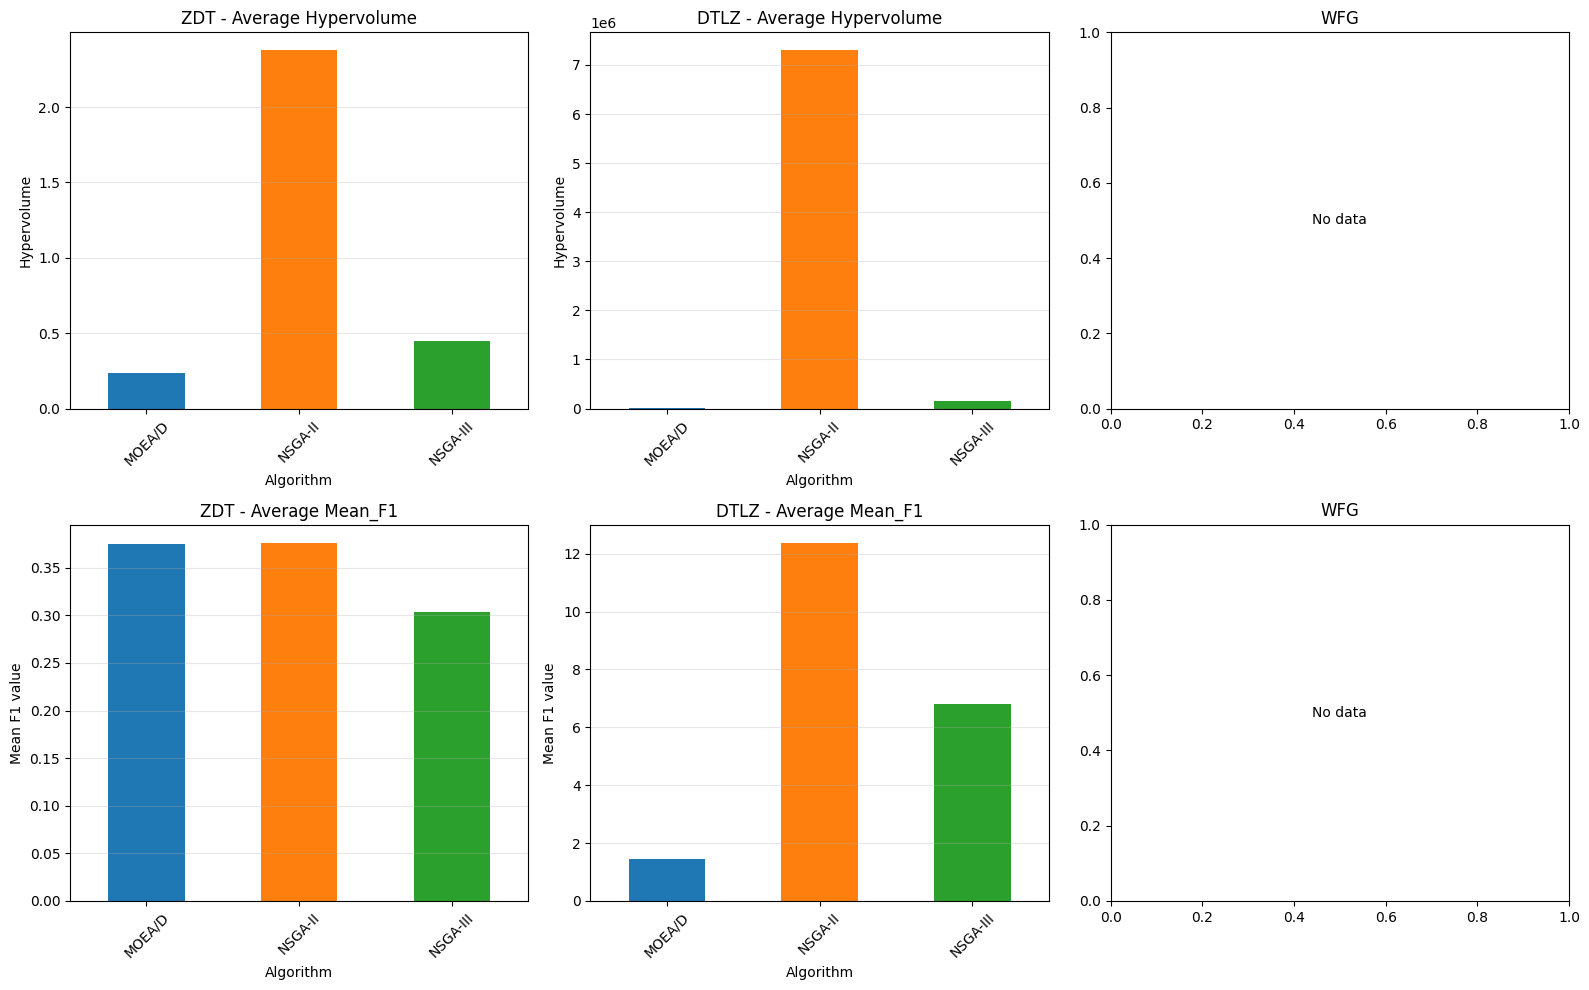


График сохранен в /tmp/benchmark_hv_and_f1_comparison.png


In [22]:
# Визуализация Hypervolume и средних значений F по алгоритмам
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Первый ряд - Hypervolume
for idx, (df, title) in enumerate([
    (zdt_df, 'ZDT'),
    (dtlz_df, 'DTLZ'),
    (wfg_df, 'WFG')
]):
    if len(df) > 0:
        hv_means = df.groupby('Algorithm')['Hypervolume'].mean()
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        hv_means.plot(kind='bar', ax=axes[0, idx], color=colors[:len(hv_means)])
        axes[0, idx].set_title(f'{title} - Average Hypervolume')
        axes[0, idx].set_ylabel('Hypervolume')
        axes[0, idx].set_xlabel('Algorithm')
        axes[0, idx].grid(axis='y', alpha=0.3)
        axes[0, idx].tick_params(axis='x', rotation=45)
    else:
        axes[0, idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[0, idx].set_title(title)

# Второй ряд - Average Mean_F1
for idx, (df, title) in enumerate([
    (zdt_df, 'ZDT'),
    (dtlz_df, 'DTLZ'),
    (wfg_df, 'WFG')
]):
    if len(df) > 0:
        algo_means = df.groupby('Algorithm')['Mean_F1'].mean()
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        algo_means.plot(kind='bar', ax=axes[1, idx], color=colors[:len(algo_means)])
        axes[1, idx].set_title(f'{title} - Average Mean_F1')
        axes[1, idx].set_ylabel('Mean F1 value')
        axes[1, idx].set_xlabel('Algorithm')
        axes[1, idx].grid(axis='y', alpha=0.3)
        axes[1, idx].tick_params(axis='x', rotation=45)
    else:
        axes[1, idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[1, idx].set_title(title)

plt.tight_layout()
plt.savefig('/tmp/benchmark_hv_and_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен в /tmp/benchmark_hv_and_f1_comparison.png")

In [23]:
# Сохранение результатов в CSV
all_results.to_csv('/tmp/benchmark_results_all.csv', index=False)
zdt_df.to_csv('/tmp/benchmark_results_zdt.csv', index=False)
dtlz_df.to_csv('/tmp/benchmark_results_dtlz.csv', index=False)
wfg_df.to_csv('/tmp/benchmark_results_wfg.csv', index=False)

print("Результаты сохранены:")
print("  - /tmp/benchmark_results_all.csv")
print("  - /tmp/benchmark_results_zdt.csv")
print("  - /tmp/benchmark_results_dtlz.csv")
print("  - /tmp/benchmark_results_wfg.csv")

# Вывод итогового резюме
print("\n" + "="*80)
print("ИТОГОВОЕ РЕЗЮМЕ")
print("="*80)

if len(all_results) > 0:
    summary_stats = all_results.groupby('Algorithm').agg({
        'N_Solutions': ['count', 'mean', 'std'],
        'Mean_F1': ['mean', 'std'],
        'Hypervolume': ['mean', 'std', 'min', 'max'],
    }).round(3)

    print("\nОбщая статистика по алгоритмам:")
    print(summary_stats)

    # Определяем лучший алгоритм по среднему количеству решений
    best_algo_count = all_results.groupby('Algorithm')['N_Solutions'].mean().idxmax()
    print(f"\n✓ Лучший алгоритм по среднему количеству решений: {best_algo_count}")

    # Определяем лучший алгоритм по качеству (минимум Mean_F1)
    best_algo_quality = all_results.groupby('Algorithm')['Mean_F1'].mean().idxmin()
    print(f"✓ Лучший алгоритм по качеству решений (Mean_F1): {best_algo_quality}")
    
    # Определяем лучший алгоритм по Hypervolume (максимум HV)
    best_algo_hv = all_results.groupby('Algorithm')['Hypervolume'].mean().idxmax()
    print(f"✓ Лучший алгоритм по Hypervolume: {best_algo_hv}")
    
    # Статистика Hypervolume по алгоритмам
    print("\n" + "-"*80)
    print("Детальная статистика Hypervolume:")
    hv_stats = all_results.groupby('Algorithm')['Hypervolume'].agg(['count', 'mean', 'std', 'min', 'max']).round(3)
    print(hv_stats)
else:
    print("No results available for summary")

Результаты сохранены:
  - /tmp/benchmark_results_all.csv
  - /tmp/benchmark_results_zdt.csv
  - /tmp/benchmark_results_dtlz.csv
  - /tmp/benchmark_results_wfg.csv

ИТОГОВОЕ РЕЗЮМЕ

Общая статистика по алгоритмам:
          N_Solutions                 Mean_F1          Hypervolume  \
                count    mean     std    mean     std         mean   
Algorithm                                                            
MOEA/D             13  35.462  25.330   0.954   1.335       69.618   
NSGA-II            13  24.846   8.792   6.842  19.369  3930848.094   
NSGA-III           13  14.000  12.042   3.797   9.999    81310.708   

                                              
                    std    min           max  
Algorithm                                     
MOEA/D     2.072290e+02  0.000  7.439220e+02  
NSGA-II    1.385207e+07  0.084  5.002265e+07  
NSGA-III   2.887444e+05  0.000  1.042216e+06  

✓ Лучший алгоритм по среднему количеству решений: MOEA/D
✓ Лучший алгоритм по качес